In [1]:
import pandas as pd
import numpy as np
import os
from PIL import Image
import re
import string
import nltk
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Embedding, Conv1D, GlobalMaxPooling1D, Concatenate, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf

In [2]:
df = pd.read_csv('Quantile/youtube_enriched_cluster.csv')
print("Dataset shape:", df.shape)
df['performa'].value_counts()

Dataset shape: (1036, 25)


performa
rendah    517
sedang    401
tinggi    118
Name: count, dtype: int64

In [3]:
df.isnull().sum()

Id                      0
Channel                 0
Category                0
Title                   0
view_count              0
like_count              0
comment_count           0
subscriber_count        0
thumbnail_path          0
view_ratio              0
performa                0
publishedAt             0
publish_time            0
video_age_days          0
view_rate               0
like_rate               0
comment_rate            0
engagement_rate         0
cluster_performa        0
cluster_label           0
log_view_count          0
log_like_count          0
log_comment_count       0
log_subscriber_count    0
performa_baru           0
dtype: int64

In [4]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [5]:
# Data Cleaning Gambar: cek validitas file gambar, hapus yang corrupt/kecil
thumbnail_folder = 'thumbnails'

def is_valid_image(path):
    try:
        with Image.open(path) as img:
            return img.size[0] >= 100 and img.size[1] >= 100
    except:
        return False

In [6]:
# Validasi thumbnail
df['thumbnail_exists'] = df['thumbnail_path'].apply(lambda p: os.path.exists(p) and is_valid_image(p))
df = df[df['thumbnail_exists']].copy()
print(f"Valid images: {len(df)}")

Valid images: 1036


In [7]:
# Preprocessing Judul: lowercase, remove non-alpha, stopwords, tokenizing, padding
stop_words = set(stopwords.words('indonesian'))

In [8]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = ' '.join([w for w in text.split() if w not in stop_words and len(w) > 1])
    return text

In [9]:
# Bersihkan judul
df['clean_title'] = df['Title'].apply(clean_text)

In [10]:
# Hapus baris dengan judul kosong setelah cleaning
df = df[df['clean_title'].str.len() > 0].copy()
print(f"Data after text cleaning: {len(df)}")

Data after text cleaning: 1032


In [11]:
MAX_NUM_WORDS = 10000
MAX_SEQ_LENGTH = 15

In [12]:
tokenizer = Tokenizer(num_words=MAX_NUM_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean_title'])
sequences = tokenizer.texts_to_sequences(df['clean_title'])
padded_sequences = pad_sequences(sequences, maxlen=MAX_SEQ_LENGTH, padding='post')

In [13]:
# Encode label performa
le = LabelEncoder()
df['performa_encoded_int'] = le.fit_transform(df['performa'])
df['performa_encoded'] = df['performa_encoded_int'].astype(str)  # String untuk ImageDataGenerator
num_classes = len(le.classes_)
print(f"Number of classes: {num_classes}")
print(f"Classes: {le.classes_}")

Number of classes: 3
Classes: ['rendah' 'sedang' 'tinggi']


In [14]:
# Split data
train_df = df.sample(frac=0.8, random_state=42)
val_df = df.drop(train_df.index).reset_index(drop=True)
train_df = train_df.reset_index(drop=True)

print(f"Train size: {len(train_df)}, Val size: {len(val_df)}")

Train size: 826, Val size: 206


In [15]:
# Hitung class weights untuk mengatasi imbalanced data
class_weights = compute_class_weight(
    'balanced', 
    classes=np.unique(train_df['performa_encoded_int']), 
    y=train_df['performa_encoded_int']
)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class weights: {class_weight_dict}")

Class weights: {0: 0.6715447154471544, 1: 0.857736240913811, 2: 2.898245614035088}


# Data Generator untuk Gambar

In [16]:
# Data augmentation untuk gambar
train_augmentor = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode='nearest'
)

val_augmentor = ImageDataGenerator(rescale=1./255)

batch_size = 32

# Generator untuk gambar
train_image_gen = train_augmentor.flow_from_dataframe(
    dataframe=train_df,
    directory='.',
    x_col='thumbnail_path',
    y_col='performa_encoded',
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
    seed=42,
    shuffle=True
)

val_image_gen = val_augmentor.flow_from_dataframe(
    dataframe=val_df,
    directory='.',
    x_col='thumbnail_path',
    y_col='performa_encoded',
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
    seed=42,
    shuffle=False
)

Found 826 validated image filenames belonging to 3 classes.
Found 206 validated image filenames belonging to 3 classes.


In [17]:
# Prepare text data
train_text_sequences = padded_sequences[train_df.index]
val_text_sequences = padded_sequences[val_df.index]

train_text_labels = to_categorical(train_df['performa_encoded_int'], num_classes=num_classes)
val_text_labels = to_categorical(val_df['performa_encoded_int'], num_classes=num_classes)

# **Arsitektur Model**

In [18]:
# Model Architecture
vocab_size = MAX_NUM_WORDS
embedding_dim = 100

In [19]:
# Input gambar (Visual Branch) - Sesuai Gambar 3.5
image_input = Input(shape=(224, 224, 3), name='image_input')

# Conv2D + ReLU (32 filter, kernel 3x3)
x = Conv2D(32, (3, 3), activation='relu')(image_input)

# MaxPooling2D (2x2)
x = MaxPooling2D(2, 2)(x)

# Flatten Layer
x = Flatten()(x)

# Dense Layer untuk ekstraksi fitur gambar
image_features = x

In [20]:
# Input teks (Text Branch) - Sesuai Proposal
text_input = Input(shape=(MAX_SEQ_LENGTH,), name='text_input')

# Tokenizer sudah dilakukan di preprocessing
# Embedding Layer
embedding = Embedding(vocab_size, embedding_dim, input_length=MAX_SEQ_LENGTH)(text_input)

# Conv1D (128 filter, kernel size 3)
conv1d = Conv1D(128, 3, activation='relu')(embedding)

# Global Max Pooling untuk menggantikan Dense Layer (Text)
text_features = GlobalMaxPooling1D()(conv1d)

In [21]:
# Concatenation Layer - Menggabungkan fitur gambar dan teks
combined = Concatenate()([image_features, text_features])

# Multilayer Perceptron (MLP) - Fully Connected Layers
fc = Dense(128, activation='relu')(combined)

# Output Layer (Softmax) - 3 kelas: rendah, sedang, tinggi
output = Dense(num_classes, activation='softmax')(fc)

In [22]:
model = Model(inputs=[image_input, text_input], outputs=output)

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 image_input (InputLayer)       [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 text_input (InputLayer)        [(None, 15)]         0           []                               
                                                                                                  
 conv2d (Conv2D)                (None, 222, 222, 32  896         ['image_input[0][0]']            
                                )                                                                 
                                                                                              

# **Training Model**

In [23]:
# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_model.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

In [24]:
# Generator gabungan yang sudah diperbaiki
class CombinedGenerator(tf.keras.utils.Sequence):
    def __init__(self, image_gen, text_sequences, text_labels, batch_size):
        self.image_gen = image_gen
        self.text_sequences = text_sequences
        self.text_labels = text_labels
        self.batch_size = batch_size
        self.indices = np.arange(len(text_sequences))
        
    def __len__(self):
        return len(self.text_sequences) // self.batch_size
    
    def __getitem__(self, idx):
        # Get image batch
        img_batch, img_labels = self.image_gen[idx]
        
        # Get corresponding text batch
        start_idx = idx * self.batch_size
        end_idx = min(start_idx + self.batch_size, len(self.text_sequences))
        
        text_batch = self.text_sequences[start_idx:end_idx]
        text_labels_batch = self.text_labels[start_idx:end_idx]
        
        # Ensure same batch size
        min_batch_size = min(len(img_batch), len(text_batch))
        
        return (
            {
                'image_input': img_batch[:min_batch_size],
                'text_input': text_batch[:min_batch_size]
            },
            img_labels[:min_batch_size]
        )
    
    def on_epoch_end(self):
        self.image_gen.on_epoch_end()

In [25]:
# Create combined generators
train_gen_combined = CombinedGenerator(
    train_image_gen, 
    train_text_sequences, 
    train_text_labels, 
    batch_size
)

val_gen_combined = CombinedGenerator(
    val_image_gen, 
    val_text_sequences, 
    val_text_labels, 
    batch_size
)

In [26]:
# Training
train_steps = len(train_gen_combined)
val_steps = len(val_gen_combined)

print(f"Training steps: {train_steps}, Validation steps: {val_steps}")

history = model.fit(
    train_gen_combined,
    epochs=50,
    steps_per_epoch=train_steps,
    validation_data=val_gen_combined,
    validation_steps=val_steps,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

Training steps: 25, Validation steps: 6
Epoch 1/50
25/25 [==============================] - ETA: 0s - loss: 13.9609 - accuracy: 0.5450
Epoch 1: val_loss improved from inf to 0.82205, saving model to best_model.h5
25/25 [==============================] - 12s 187ms/step - loss: 13.9609 - accuracy: 0.5450 - val_loss: 0.8221 - val_accuracy: 0.8542 - lr: 0.0010
Epoch 2/50
25/25 [==============================] - ETA: 0s - loss: 1.0324 - accuracy: 0.8050
Epoch 2: val_loss improved from 0.82205 to 0.70695, saving model to best_model.h5
25/25 [==============================] - 9s 365ms/step - loss: 1.0324 - accuracy: 0.8050 - val_loss: 0.7069 - val_accuracy: 0.8177 - lr: 0.0010
Epoch 3/50
25/25 [==============================] - ETA: 0s - loss: 0.5818 - accuracy: 0.8213
Epoch 3: val_loss improved from 0.70695 to 0.40757, saving model to best_model.h5
25/25 [==============================] - 8s 304ms/step - loss: 0.5818 - accuracy: 0.8213 - val_loss: 0.4076 - val_accuracy: 0.9010 - lr: 0.0010
E

In [27]:
# Save final model
model.save('final_multimodal_model.h5')
print("Model saved successfully!")

Model saved successfully!


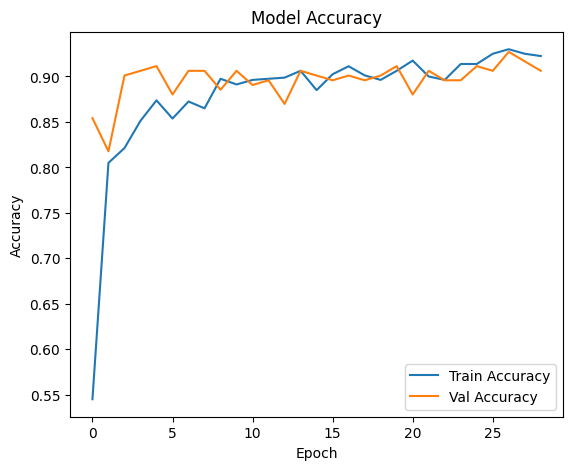

In [28]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

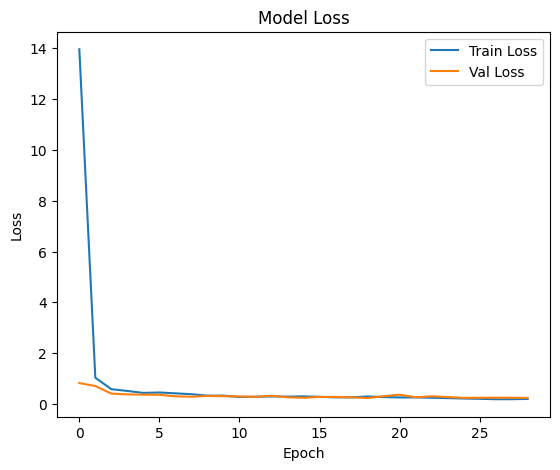

In [29]:
# Plot training & validation accuracy values
plt.figure(figsize=(14, 5))

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Evaluasi model terhadap validation/test data
val_loss, val_accuracy = model.evaluate(val_gen_combined, steps=val_steps)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")

# Prediksi untuk seluruh validation set
y_true = []
y_pred = []

for i in range(len(val_gen_combined)):
    x_batch, y_batch = val_gen_combined[i]
    y_pred_batch = model.predict(x_batch)
    
    y_true.extend(np.argmax(y_batch, axis=1))         # true label
    y_pred.extend(np.argmax(y_pred_batch, axis=1))    # predicted label

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred))

6/6 [==============================] - 0s 46ms/step - loss: 0.2355 - accuracy: 0.9010
Validation Loss: 0.23551850020885468
Validation Accuracy: 0.9010416865348816
1/1 [==============================] - 0s 22ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.92        96
           1       0.92      0.91      0.91        75
           2       0.74      0.81      0.77        21

    accuracy                           0.90       192
   macro avg       0.86      0.88      0.87       192
weighted avg       0.90      0.90      0.90       192



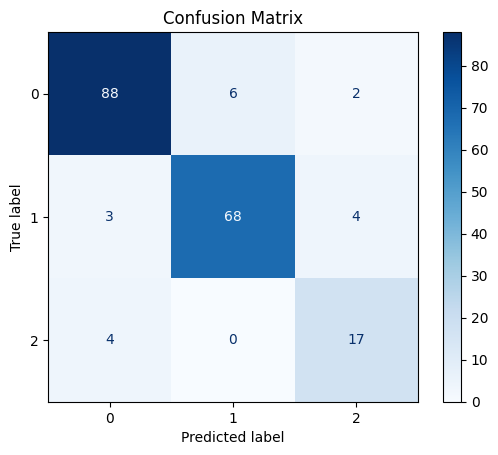

In [31]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()